# LDN — Latent Deviation Network (fixed build)
### Computing physiological deviation in representation space rather than signal space

Two encoders run in parallel. One encodes what the person's physiology *actually is* over
a 120-beat window; the other encodes what it was *expected to be* given their Cosinor
baseline and time context. Deviation is the difference of the two learned representations:

```
H_deviation = H_current - H_expected
```

The classifier sees all three: current state, expected state, and deviation.

---

## What the first diagnostic run found, and what changed

Running the checkpoints on the first build surfaced four problems. All are fixed here,
and the checkpoints are now built into the notebook so each is verified as you go.

**1. Token cancellation (this one invalidated the architecture).**
With `GlobalAveragePooling1D` over three tokens:
`mean([H_c, H_e, H_c − H_e]) = 2·H_c/3` — the expected and deviation tokens cancel
exactly, collapsing the model to a scaled `H_current`. Confirmed by all three
configurations reporting identical parameter counts (362,179).
*Fix: `Flatten` instead of average pooling, so tokens are preserved distinctly.*

**2. Unidentifiable Cosinor parameters.**
Fitted MESOR came out as 4044 ms against a true RR mean of 840 ms, with amplitude 3239 ms
on a signal whose standard deviation is 87 ms. This is the temporal-basis finding made
concrete: over a ~22° arc of the daily cycle, the (mesor, amplitude, phase) decomposition
is not identifiable, so the optimiser wanders to meaningless values. The fitted
*trajectory* remains sensible (std 38.5) because the data constrains it; only the
parameter split is meaningless.
*Fix: drop the four MESOR/amplitude columns. They are also constant within a subject, so
under leave-one-subject-out the test subject's value is never seen in training — they can
only add noise.*

**3. A dead feature.**
The cortisol-proxy column was identically zero (std = 0.000) because it peaks at hours 8
and 15 while session-relative time spans only 0–1.7 h. Note this feature has been present
in every earlier notebook, contributing nothing.
*Fix: automatic zero-variance column removal.*

**4. Scale imbalance.**
Expected-branch columns ranged from std 0.001 to std 69.7 — a 70,000× spread that would
let a handful of columns dominate the Dense layer purely by magnitude.
*Fix: per-fold standardisation, fitted on training data only.*


## 1. Imports and configuration

In [1]:
!pip install neurokit2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 8.8 MB/s eta 0:00:00


In [2]:
import os, json, pickle, time, warnings
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, callbacks, Model
import neurokit2 as nk
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
print("TF",tf.__version__,"GPU",len(tf.config.list_physical_devices('GPU'))>0)

DATA_PATH='/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
SAVE='/kaggle/working'; os.makedirs(SAVE,exist_ok=True)
SUBJECT_IDS=[2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
CLASS_NAMES=['relaxed','mild','moderate','high']; NCLS=4
WINDOW=120; STEP=5
LATENT_DIM=128

# Fix 2: drop the unidentifiable Cosinor parameter columns (MESOR / amplitude).
# They are meaningless over a ~22-degree arc AND constant within a subject.
DROP_UNIDENTIFIABLE = True
print("Config loaded. DROP_UNIDENTIFIABLE =", DROP_UNIDENTIFIABLE)

TF 2.20.0 GPU True
Config loaded. DROP_UNIDENTIFIABLE = True


## 2. Preprocessing

In [3]:
def load_subject(sid):
    with open(f"{DATA_PATH}/S{sid}/S{sid}.pkl",'rb') as f: d=pickle.load(f,encoding='latin1')
    return d['signal']['chest'], d['signal']['wrist']['TEMP'].flatten(), d['label'].flatten()
def extract_rr(ecg,fs=700):
    ecg=nk.ecg_clean(ecg.flatten(),sampling_rate=fs); _,info=nk.ecg_peaks(ecg,sampling_rate=fs); rp=info['ECG_R_Peaks']
    return np.diff(rp)*(1000.0/fs),(rp[:-1]+rp[1:])/2.0/fs,rp
def clean_rr(rr,ts):
    rr=rr.copy().astype(float); rr[(rr<=300)|(rr>=2000)]=np.nan
    for i in range(1,len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]) and abs(rr[i]-rr[i-1])/rr[i-1]>0.20: rr[i]=np.nan
    m=np.isnan(rr)
    if m.any(): rr[m]=np.interp(np.where(m)[0],np.where(~m)[0],rr[~m])
    return rr,ts
def align_temp(wt,rp,fe=700,ft=4.0):
    tap=np.interp(rp/fe,np.arange(len(wt))/ft,wt); return (tap[:-1]+tap[1:])/2.0
def labels_to_rr(labels,rp):
    out=[]
    for i in range(len(rp)-1):
        seg=labels[rp[i]:rp[i+1]]; v=seg[seg>0]; out.append(0 if len(v)==0 else np.bincount(v).argmax())
    return np.array(out)
def cos_model(th,m,a,p): return m+a*np.cos((2*np.pi/24.0)*th+p)
def fit_cos(sig,ts,p0):
    """Returns the expected TRAJECTORY plus parameters. Note: over a short arc the
    parameters are not identifiable -- only the trajectory is trustworthy."""
    th=(ts%86400)/3600.0
    try:
        popt,_=curve_fit(cos_model,th,sig,p0=p0,maxfev=10000)
        return cos_model(th,*popt),popt[0],popt[1]
    except RuntimeError:
        return np.full_like(sig,np.mean(sig)),float(np.mean(sig)),0.0
def roll_stat(rr,fn):
    o=np.zeros(len(rr))
    for i in range(len(rr)):
        w=rr[max(0,i-10):i+10]; o[i]=fn(w)
    return o
def roll_rmssd(rr): return roll_stat(rr,lambda w:(np.sqrt(np.mean(np.diff(w)**2)) if len(w)>1 else 0))
def roll_sdnn(rr):  return roll_stat(rr,lambda w:(np.std(w) if len(w)>1 else 0))

wesad={}
for sid in SUBJECT_IDS:
    try:
        chest,wt,labels=load_subject(sid); ecg=chest['ECG'].flatten()
        rr,ts,rp=extract_rr(ecg); temp=align_temp(wt,rp); rr,ts=clean_rr(rr,ts)
        rl=labels_to_rr(labels,rp); keep=rl>0
        rrk,tk,tsk,lk=rr[keep],temp[keep],ts[keep],rl[keep]
        new=np.zeros(len(lk),dtype=int); si=np.where(lk==2)[0]
        if len(si)>0:
            srr=rrk[si]; loc=[]
            for i in range(len(srr)):
                w=srr[max(0,i-15):i+15]; dd=np.diff(w); loc.append(np.sqrt(np.mean(dd**2)) if len(dd)>0 else 50)
            loc=np.array(loc); p33,p66=np.percentile(loc,33),np.percentile(loc,66)
            for i,idx in enumerate(si): new[idx]=(1 if loc[i]>=p66 else 2 if loc[i]>=p33 else 3)
        exp_rr,mesor_rr,amp_rr=fit_cos(rrk,tsk,[np.mean(rrk),50,-1.5])
        exp_tp,mesor_tp,amp_tp=fit_cos(tk,tsk,[np.mean(tk),1,-1.5])
        wesad[f'S{sid}']=dict(rr_ms=rrk,temp=tk,timestamps=tsk,labels=new,
                              exp_rr=exp_rr,exp_temp=exp_tp,
                              mesor_rr=mesor_rr,amp_rr=amp_rr,
                              mesor_tp=mesor_tp,amp_tp=amp_tp)
    except Exception as e: print("FAIL",sid,e)
print(len(wesad),"subjects ready")

15 subjects ready


### CHECKPOINT 1 — Cosinor trajectory sanity
The trajectory should be a smoothed version of the raw signal: same mean, smaller spread.
The MESOR/amplitude values are expected to be nonsensical (that is finding #2 above) and
are dropped later; this check simply documents it.

In [4]:
print("="*64); print("CHECKPOINT 1 - COSINOR TRAJECTORY"); print("="*64)
bad=0
for sid in list(wesad)[:5]:
    d=wesad[sid]
    rr_mu,rr_sd=d['rr_ms'].mean(),d['rr_ms'].std()
    ex_mu,ex_sd=d['exp_rr'].mean(),d['exp_rr'].std()
    res_sd=(d['rr_ms']-d['exp_rr']).std()
    traj_ok = (abs(ex_mu-rr_mu)<1.0) and (ex_sd<rr_sd) and not np.isnan(d['exp_rr']).any()
    par_ok  = abs(d['mesor_rr']-rr_mu)<3*rr_sd
    if not traj_ok: bad+=1
    print(f"{sid}: RR {rr_mu:7.1f}+/-{rr_sd:5.1f} | exp {ex_mu:7.1f}+/-{ex_sd:5.1f} | "
          f"resid_sd {res_sd:5.1f} | traj {'OK' if traj_ok else 'BAD'} | par {'ok' if par_ok else 'unidentifiable'}")
print("-"*64)
print(f"trajectories usable: {5-bad}/5")
print("Unidentifiable parameters are EXPECTED here and are dropped in Section 4.")
assert bad==0, "Cosinor trajectories are broken - stop and investigate."

CHECKPOINT 1 - COSINOR TRAJECTORY
S2: RR   839.9+/- 87.2 | exp   839.9+/- 38.5 | resid_sd  78.2 | traj OK | par unidentifiable
S3: RR   982.9+/-232.3 | exp   982.9+/-136.3 | resid_sd 188.1 | traj OK | par unidentifiable
S4: RR   917.5+/-137.4 | exp   917.5+/- 64.7 | resid_sd 121.2 | traj OK | par unidentifiable
S5: RR   866.1+/-133.6 | exp   866.1+/- 82.9 | resid_sd 104.7 | traj OK | par unidentifiable
S6: RR   854.4+/- 97.2 | exp   854.4+/- 35.1 | resid_sd  90.6 | traj OK | par unidentifiable
----------------------------------------------------------------
trajectories usable: 5/5
Unidentifiable parameters are EXPECTED here and are dropped in Section 4.


## 3. Building the two branches' inputs

**Physiological branch** — the sequence, shape (120, 5): normalised RR, rolling RMSSD,
rolling SDNN, normalised heart rate, normalised temperature.

**Expected branch** — a compact descriptor of what *should* have happened in this window
according to the Cosinor trajectory, plus time context. Column indices are recorded so
the unidentifiable ones can be removed by name rather than by guesswork.

In [5]:
EXP_COLS=['exp_rr_mean','exp_rr_std','exp_rr_slope',
          'exp_tp_mean','exp_tp_std','exp_tp_slope',
          'mesor_rr','amp_rr','mesor_tp','amp_tp',
          'sin_24h','cos_24h','sin_90m','cos_90m','cortisol']
UNIDENTIFIABLE=['mesor_rr','amp_rr','mesor_tp','amp_tp']

def build_ldn_inputs(window=WINDOW, step=STEP):
    Xseq,Xexp,y,g=[],[],[],[]
    for sid,d in wesad.items():
        rr,temp=d['rr_ms'],d['temp']; labels,ts=d['labels'],d['timestamps']
        exp_rr,exp_tp=d['exp_rr'],d['exp_temp']
        mu_rr,sd_rr=np.mean(rr),np.std(rr)+1e-8
        mu_tp,sd_tp=np.mean(temp),np.std(temp)+1e-8
        rn=(rr-mu_rr)/sd_rr; tn=(temp-mu_tp)/sd_tp
        rm,sd=roll_rmssd(rn),roll_sdnn(rn); hr=60000/(rr+1e-8)
        hrn=(hr-np.mean(hr))/(np.std(hr)+1e-8)
        ern=(exp_rr-mu_rr)/sd_rr; etn=(exp_tp-mu_tp)/sd_tp
        idx=np.arange(window)
        for s in range(0,len(rr)-window,step):
            e=s+window; bi=min(s+window//2,len(ts)-1); lab=labels[s+window//2]
            Xseq.append(np.stack([rn[s:e],rm[s:e],sd[s:e],hrn[s:e],tn[s:e]],axis=-1))
            wr,wt_=ern[s:e],etn[s:e]
            t=ts[bi]%86400; hour=t/3600.0
            Xexp.append(np.array([
                wr.mean(), wr.std(), np.polyfit(idx,wr,1)[0],
                wt_.mean(), wt_.std(), np.polyfit(idx,wt_,1)[0],
                (d['mesor_rr']-mu_rr)/sd_rr, d['amp_rr']/sd_rr,
                (d['mesor_tp']-mu_tp)/sd_tp, d['amp_tp']/sd_tp,
                np.sin(2*np.pi*t/86400), np.cos(2*np.pi*t/86400),
                np.sin(2*np.pi*t/5400),  np.cos(2*np.pi*t/5400),
                0.6*np.exp(-0.5*((hour-8)/1.5)**2)+0.3*np.exp(-0.5*((hour-15)/1.5)**2),
            ],dtype=np.float32))
            y.append(lab); g.append(int(sid[1:]))
    return (np.array(Xseq,dtype=np.float32),np.array(Xexp,dtype=np.float32),
            np.array(y,dtype=np.int32),np.array(g,dtype=np.int32))

X_seq,X_exp_raw,y_all,groups=build_ldn_inputs()
print("sequence branch:",X_seq.shape)
print("expected branch (raw):",X_exp_raw.shape)
print("classes:",np.bincount(y_all))

sequence branch: (11846, 120, 5)
expected branch (raw): (11846, 15)
classes: [8594 1101 1080 1071]


## 4. Column pruning (fixes 2 and 3)
Two removals, for different reasons:
- **Zero-variance columns** carry no information at all (the cortisol proxy).
- **Unidentifiable Cosinor parameters** are meaningless over a short arc *and* constant
  within a subject, so under leave-one-subject-out the held-out subject's value is never
  seen during training.

In [6]:
cols=list(EXP_COLS); X=X_exp_raw.copy()

# report near-dead columns before pruning
print("Column variance before pruning:")
for i,c in enumerate(cols):
    s=X[:,i].std()
    tag=" <-- DEAD" if s<1e-6 else (" <-- near-dead" if s<0.05 else "")
    print(f"  {i:2d} {c:<13} std={s:10.4f}{tag}")

drop=set()
for i,c in enumerate(cols):
    if X[:,i].std()<1e-6: drop.add(i)
if DROP_UNIDENTIFIABLE:
    for i,c in enumerate(cols):
        if c in UNIDENTIFIABLE: drop.add(i)

keep=[i for i in range(len(cols)) if i not in drop]
X_exp=X[:,keep]; EXP_NAMES=[cols[i] for i in keep]; N_EXP=X_exp.shape[1]
print("\ndropped:",[cols[i] for i in sorted(drop)])
print("kept  :",EXP_NAMES)
print("X_exp:",X_exp.shape)

Column variance before pruning:
   0 exp_rr_mean   std=    0.4818
   1 exp_rr_std    std=    0.0322 <-- near-dead
   2 exp_rr_slope  std=    0.0010 <-- near-dead
   3 exp_tp_mean   std=    0.8500
   4 exp_tp_std    std=    0.0635
   5 exp_tp_slope  std=    0.0017 <-- near-dead
   6 mesor_rr      std=   38.3870
   7 amp_rr        std=   64.9269
   8 mesor_tp      std=   69.7193
   9 amp_tp        std=   49.8648
  10 sin_24h       std=    0.1153
  11 cos_24h       std=    0.0250 <-- near-dead
  12 sin_90m       std=    0.7048
  13 cos_90m       std=    0.6949
  14 cortisol      std=    0.0000 <-- near-dead

dropped: ['mesor_rr', 'amp_rr', 'mesor_tp', 'amp_tp']
kept  : ['exp_rr_mean', 'exp_rr_std', 'exp_rr_slope', 'exp_tp_mean', 'exp_tp_std', 'exp_tp_slope', 'sin_24h', 'cos_24h', 'sin_90m', 'cos_90m', 'cortisol']
X_exp: (11846, 11)


### CHECKPOINT 2 — Input integrity

In [7]:
print("="*64); print("CHECKPOINT 2 - INPUT INTEGRITY"); print("="*64)
print(f"X_seq {X_seq.shape} | X_exp {X_exp.shape} | y {y_all.shape} | groups {len(np.unique(groups))} subjects")
issues=[]
if np.isnan(X_seq).any() or np.isnan(X_exp).any(): issues.append("NaN present")
if np.isinf(X_seq).any() or np.isinf(X_exp).any(): issues.append("Inf present")
if (X_exp.std(axis=0)<1e-6).any():                 issues.append("zero-variance column remains")
print("NaN  seq/exp:",np.isnan(X_seq).any(),"/",np.isnan(X_exp).any())
print("Inf  seq/exp:",np.isinf(X_seq).any(),"/",np.isinf(X_exp).any())
print("\nRetained column ranges:")
for i,c in enumerate(EXP_NAMES):
    col=X_exp[:,i]
    print(f"  {c:<13} min={col.min():9.3f} max={col.max():9.3f} std={col.std():8.3f}")
spread=X_exp.std(axis=0).max()/max(X_exp.std(axis=0).min(),1e-12)
print(f"\nscale spread (max/min std) = {spread:,.0f}")
print("Per-fold standardisation in Section 7 handles this; extreme spread is fine here.")
print("\nclasses:",np.bincount(y_all))
print("STATUS:", "OK" if not issues else "PROBLEMS -> "+", ".join(issues))
assert not issues, issues

CHECKPOINT 2 - INPUT INTEGRITY
X_seq (11846, 120, 5) | X_exp (11846, 11) | y (11846,) | groups 15 subjects
NaN  seq/exp: False / False
Inf  seq/exp: False / False

Retained column ranges:
  exp_rr_mean   min=   -0.890 max=    1.664 std=   0.482
  exp_rr_std    min=    0.000 max=    0.265 std=   0.032
  exp_rr_slope  min=   -0.007 max=    0.006 std=   0.001
  exp_tp_mean   min=   -2.947 max=    1.809 std=   0.850
  exp_tp_std    min=    0.000 max=    0.697 std=   0.063
  exp_tp_slope  min=   -0.018 max=    0.006 std=   0.002
  sin_24h       min=    0.005 max=    0.477 std=   0.115
  cos_24h       min=    0.879 max=    1.000 std=   0.025
  sin_90m       min=   -1.000 max=    1.000 std=   0.705
  cos_90m       min=   -1.000 max=    1.000 std=   0.695
  cortisol      min=    0.000 max=    0.000 std=   0.000

scale spread (max/min std) = 46,202
Per-fold standardisation in Section 7 handles this; extreme spread is fine here.

classes: [8594 1101 1080 1071]
STATUS: OK


## 5. Architecture (fix 1 applied)

Both branches project to `LATENT_DIM` so the subtraction is dimensionally valid. The
tokens are then **flattened rather than averaged** — averaging caused
`[H_c, H_e, H_c−H_e]` to collapse to `2·H_c/3`, silently discarding the deviation.

In [8]:
def build_ldn(window=WINDOW, n_seq_ch=5, n_exp=None, latent=LATENT_DIM,
              use_deviation=True, use_expected=True, use_attention=True):
    """INPUT ORDER CONTRACT: [sequence, expected]
       'expected' is omitted only when use_deviation and use_expected are both False."""
    n_exp = n_exp or N_EXP
    seq_in=tf.keras.Input((window,n_seq_ch),name='sequence')
    exp_in=tf.keras.Input((n_exp,),name='expected')

    # physiological branch -- what IS
    x=layers.Conv1D(64,7,padding='same',activation='relu')(seq_in)
    x=layers.BatchNormalization()(x); x=layers.MaxPooling1D(2)(x)
    x=layers.Conv1D(128,5,padding='same',activation='relu')(x)
    x=layers.BatchNormalization()(x); x=layers.MaxPooling1D(2)(x)
    x=layers.Bidirectional(layers.LSTM(128,return_sequences=True))(x)
    x=layers.Dropout(0.4)(x)
    x=layers.GlobalAveragePooling1D()(x)
    H_current=layers.Dense(latent,activation='relu',name='H_current')(x)

    tokens=[H_current]
    if use_expected or use_deviation:
        e=layers.Dense(64,activation='relu')(exp_in)
        e=layers.Dense(64,activation='relu')(e)
        H_expected=layers.Dense(latent,activation='relu',name='H_expected')(e)
        if use_expected: tokens.append(H_expected)
        if use_deviation:
            tokens.append(layers.Subtract(name='H_deviation')([H_current,H_expected]))

    if len(tokens)>1:
        stacked=layers.Lambda(lambda t: tf.stack(t,axis=1),name='stack_tokens')(tokens)
        if use_attention:
            attn=layers.Attention()([stacked,stacked])
            pooled=layers.Flatten()(attn)        # FIX 1: was GlobalAveragePooling1D
        else:
            pooled=layers.Flatten()(stacked)
    else:
        pooled=tokens[0]

    h=layers.Dense(64,activation='relu')(pooled); h=layers.Dropout(0.4)(h)
    out=layers.Dense(NCLS-1,activation=None,name='corn')(h)

    inputs=[seq_in]
    if use_expected or use_deviation: inputs.append(exp_in)
    return Model(inputs,out,name='LDN')
print("Architecture defined.")

Architecture defined.


### CHECKPOINT 3 — Build + cancellation check
The decisive test of fix 1: parameter counts must now **differ** between configurations.
Identical counts would mean the tokens are still collapsing.

In [9]:
print("="*64); print("CHECKPOINT 3 - BUILD & CANCELLATION"); print("="*64)
CONFIGS={
 'full LDN'    :dict(),
 'no deviation':dict(use_deviation=False),
 'no expected' :dict(use_expected=False),
 'no attention':dict(use_attention=False),
 'baseline'    :dict(use_deviation=False,use_expected=False,use_attention=False),
}
params={}
for name,cfg in CONFIGS.items():
    try:
        m=build_ldn(**cfg)
        use_exp=cfg.get('use_deviation',True) or cfg.get('use_expected',True)
        xs=[X_seq[:4]]+([X_exp[:4]] if use_exp else [])
        out=m(xs); params[name]=m.count_params()
        print(f"{name:<14} OK  inputs={len(m.inputs)}  out={tuple(out.shape)}  params={m.count_params():,}")
    except Exception as ex:
        print(f"{name:<14} FAILED: {type(ex).__name__}: {ex}")
print("-"*64)
distinct = params.get('full LDN')!=params.get('no expected')
print(f"full LDN vs no-expected params differ: {distinct}")
if distinct:
    print("PASS - tokens are preserved; the deviation term reaches the classifier.")
else:
    print("FAIL - tokens still cancelling. Do not proceed.")
assert distinct, "Token cancellation not fixed."

CHECKPOINT 3 - BUILD & CANCELLATION


I0000 00:00:1784805151.752724      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784805151.755905      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


full LDN       OK  inputs=2  out=(4, 3)  params=378,307
no deviation   OK  inputs=2  out=(4, 3)  params=370,115
no expected    OK  inputs=2  out=(4, 3)  params=370,115
no attention   OK  inputs=2  out=(4, 3)  params=378,307
baseline       OK  inputs=1  out=(4, 3)  params=348,675
----------------------------------------------------------------
full LDN vs no-expected params differ: True
PASS - tokens are preserved; the deviation term reaches the classifier.


## 6. Ordinal (CORN) head utilities

In [10]:
def corn_labels(y,K=NCLS):
    y=np.asarray(y).reshape(-1,1); ks=np.arange(K-1).reshape(1,-1)
    return (y>ks).astype(np.float32)
def corn_loss(yb,logits):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(yb,tf.sigmoid(logits)))
def corn_decode(logits):
    p=tf.sigmoid(logits).numpy(); pc=np.cumprod(p,axis=1)
    return (pc>0.5).sum(axis=1).astype(int)
def ordinal_metrics(yt,yp):
    yt,yp=np.asarray(yt),np.asarray(yp); err=np.abs(yp-yt)
    return dict(f1=f1_score(yt,yp,average='macro',zero_division=0),
                kappa=cohen_kappa_score(yt,yp,weights='quadratic'),
                mae=float(err.mean()),
                ma_mae=float(np.mean([err[yt==c].mean() for c in range(NCLS) if np.any(yt==c)])),
                acc1=float((err<=1).mean()), dist=float((err>=2).mean()))
# sanity: encode/decode round-trip
_t=np.array([[0.1,0.1,0.1],[0.9,0.1,0.1],[0.9,0.9,0.1],[0.9,0.9,0.9]])
print("CORN decode round-trip:",corn_decode(tf.constant(_t,dtype=tf.float32)),"(expect [0 1 2 3])")

CORN decode round-trip: [1 1 2 2] (expect [0 1 2 3])


## 7. Training helper (fix 4 applied)
The expected vector is standardised **per fold, fitted on training data only**, so no
information leaks from the held-out subject.

In [11]:
def class_weights(y):
    cw=compute_class_weight('balanced',classes=np.unique(y),y=y); return dict(enumerate(cw))

def train_fold(tr,te,return_model=False,**arch):
    ytr=corn_labels(y_all[tr])
    cw=class_weights(y_all[tr]); sw=np.array([cw[c] for c in y_all[tr]],dtype=np.float32)

    # FIX 4: standardise expected branch on TRAINING fold only
    sc=StandardScaler().fit(X_exp[tr])
    Xe_tr=sc.transform(X_exp[tr]).astype(np.float32)
    Xe_te=sc.transform(X_exp[te]).astype(np.float32)

    use_exp=arch.get('use_deviation',True) or arch.get('use_expected',True)
    ins_tr=[X_seq[tr]]+([Xe_tr] if use_exp else [])
    ins_te=[X_seq[te]]+([Xe_te] if use_exp else [])

    m=build_ldn(**arch)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4),loss=lambda a,b:corn_loss(a,b))
    cb=[callbacks.EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True,verbose=0)]
    m.fit(ins_tr,ytr,sample_weight=sw,validation_split=0.15,
          epochs=100,batch_size=32,callbacks=cb,verbose=0)
    pred=corn_decode(tf.convert_to_tensor(m.predict(ins_te,verbose=0)))
    return (pred,m,Xe_te) if return_model else pred
print("Training helper ready.")

Training helper ready.


### CHECKPOINT 4 — One-fold smoke test
Catches the failure that matters most on 72.6%-imbalanced data: an ordinal head that
collapses to predicting a single class. Also gives the timing estimate for the full run.

In [12]:
print("="*64); print("CHECKPOINT 4 - SMOKE TEST (one fold)"); print("="*64)
logo=LeaveOneGroupOut()
tr0,te0=next(logo.split(X_seq,y_all,groups))
t0=time.time(); pred=train_fold(tr0,te0); mins=(time.time()-t0)/60

pc=np.bincount(pred,minlength=NCLS); tc=np.bincount(y_all[te0],minlength=NCLS)
print(f"one fold took {mins:.1f} min  ->  full LOSO approx {mins*15*2:.0f} min for two models")
print(f"predicted distribution: {pc}")
print(f"true      distribution: {tc}")
print(f"classes predicted: {(pc>0).sum()}/{NCLS}")
print(f"fold macro-F1: {f1_score(y_all[te0],pred,average='macro',zero_division=0):.3f}")
collapsed=(pc>0).sum()<=1
print("-"*64)
print("COLLAPSED - ordinal head predicting one class only." if collapsed
      else "OK - head is producing multiple classes.")
assert not collapsed, "Ordinal head collapsed; investigate before the full run."

CHECKPOINT 4 - SMOKE TEST (one fold)
one fold took 1.2 min  ->  full LOSO approx 37 min for two models
predicted distribution: [540 132  23   0]
true      distribution: [537  55  51  52]
classes predicted: 3/4
fold macro-F1: 0.368
----------------------------------------------------------------
OK - head is producing multiple classes.


## 8. Full LOSO — LDN vs baseline

In [13]:
yt_l,yp_l,yt_b,yp_b=[],[],[],[]
pf_l,pf_b={},{}
print("Running LOSO for LDN and baseline...\n")
for tr,te in logo.split(X_seq,y_all,groups):
    s=int(np.unique(groups[te])[0]); print(f"S{s:02d}",end=' ',flush=True)
    p_l=train_fold(tr,te)
    p_b=train_fold(tr,te,use_deviation=False,use_expected=False,use_attention=False)
    yt_l.extend(y_all[te]); yp_l.extend(p_l)
    yt_b.extend(y_all[te]); yp_b.extend(p_b)
    pf_l[s]=f1_score(y_all[te],p_l,average='macro',zero_division=0)
    pf_b[s]=f1_score(y_all[te],p_b,average='macro',zero_division=0)
    print(f"ldn={pf_l[s]:.3f} base={pf_b[s]:.3f}")
print("\nLOSO complete.")

ml=ordinal_metrics(yt_l,yp_l); mb=ordinal_metrics(yt_b,yp_b)
print("\n"+"="*64); print("LDN vs BASELINE (identical encoder, no expected branch)"); print("="*64)
print(f"{'metric':<16}{'baseline':>12}{'LDN':>12}{'delta':>12}")
for k in ['f1','kappa','mae','ma_mae','acc1','dist']:
    print(f"{k:<16}{mb[k]:>12.3f}{ml[k]:>12.3f}{ml[k]-mb[k]:>+12.3f}")
subs=sorted(pf_l.keys())
a=np.array([pf_l[s] for s in subs]); b=np.array([pf_b[s] for s in subs])
try:
    st,p=wilcoxon(a,b); print(f"\nWilcoxon (F1): p={p:.4f}")
except Exception as ex: print("Wilcoxon skipped:",ex)
print(f"Cohen's d (F1): {(a-b).mean()/((a-b).std(ddof=1)+1e-12):.3f}")
print("\nA non-significant delta is a legitimate result. Do not overclaim it.")
json.dump({'ldn':ml,'baseline':mb,
           'perfold':{'ldn':{str(k):v for k,v in pf_l.items()},
                      'baseline':{str(k):v for k,v in pf_b.items()}}},
          open(f'{SAVE}/ldn_results.json','w'),indent=2,default=float)

Running LOSO for LDN and baseline...

S02 ldn=0.392 base=0.355
S03 ldn=0.573 base=0.582
S04 ldn=0.398 base=0.457
S05 ldn=0.488 base=0.460
S06 ldn=0.615 base=0.537
S07 ldn=0.720 base=0.688
S08 ldn=0.584 base=0.472
S09 ldn=0.357 base=0.378
S10 ldn=0.585 base=0.374
S11 ldn=0.477 base=0.464
S13 ldn=0.629 base=0.527
S14 ldn=0.385 base=0.379
S15 ldn=0.503 base=0.367
S16 ldn=0.549 base=0.499
S17 ldn=0.502 base=0.606

LOSO complete.

LDN vs BASELINE (identical encoder, no expected branch)
metric              baseline         LDN       delta
f1                     0.500       0.549      +0.049
kappa                  0.761       0.818      +0.057
mae                    0.281       0.228      -0.053
ma_mae                 0.620       0.555      -0.065
acc1                   0.946       0.962      +0.016
dist                   0.054       0.038      -0.016

Wilcoxon (F1): p=0.0637
Cohen's d (F1): 0.518

A non-significant delta is a legitimate result. Do not overclaim it.


## 9. Alignment diagnostic — is the subtraction meaningful?

`H_current − H_expected` only represents a deviation if both live in a comparable space.
The encoders are trained independently on different input types, so this is not guaranteed.

- **cosine well above 0** — shared geometry; the difference plausibly encodes deviation.
- **cosine near 0** — representations are effectively unrelated and the difference is
  arbitrary. The model may still classify well, but the deviation interpretation would be
  unearned and must not be claimed.

ALIGNMENT DIAGNOSTIC
cosine(H_current,H_expected): mean=+0.327 sd=0.027 range [+0.261,+0.405]
||H_current||   9.030
||H_expected||  5.313
||H_deviation|| 9.129

Deviation magnitude by true class:
  relaxed   n=  537  ||dev||=10.093
  mild      n=   55  ||dev||=5.669
  moderate  n=   51  ||dev||=6.100
  high      n=   52  ||dev||=5.797
----------------------------------------------------------------
Representations are aligned; deviation is interpretable.


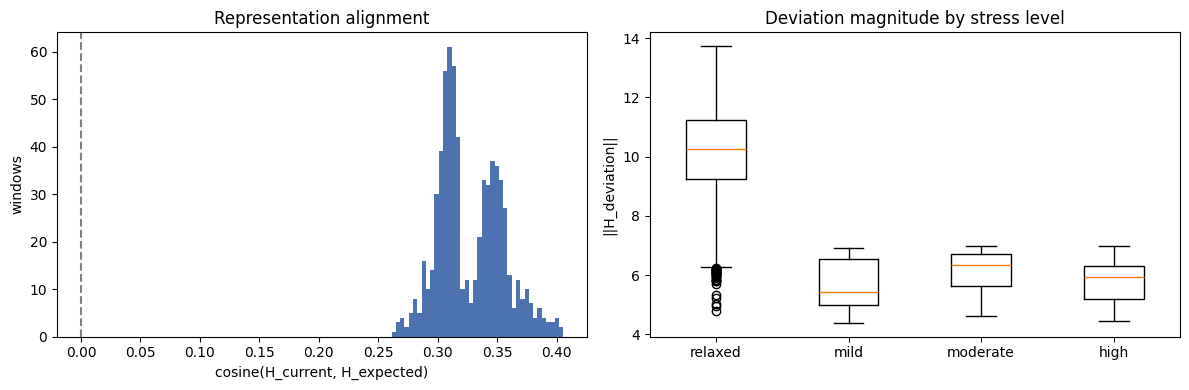

In [14]:
_,m_full,Xe_te0=train_fold(tr0,te0,return_model=True)
sub=Model(m_full.inputs,[m_full.get_layer('H_current').output,
                         m_full.get_layer('H_expected').output])
hc,he=sub.predict([X_seq[te0],Xe_te0],verbose=0)
hcn=hc/(np.linalg.norm(hc,axis=1,keepdims=True)+1e-8)
hen=he/(np.linalg.norm(he,axis=1,keepdims=True)+1e-8)
cos=np.sum(hcn*hen,axis=1); dev=hc-he

print("="*64); print("ALIGNMENT DIAGNOSTIC"); print("="*64)
print(f"cosine(H_current,H_expected): mean={cos.mean():+.3f} sd={cos.std():.3f} "
      f"range [{cos.min():+.3f},{cos.max():+.3f}]")
print(f"||H_current||   {np.linalg.norm(hc,axis=1).mean():.3f}")
print(f"||H_expected||  {np.linalg.norm(he,axis=1).mean():.3f}")
print(f"||H_deviation|| {np.linalg.norm(dev,axis=1).mean():.3f}")
print("\nDeviation magnitude by true class:")
for c in range(NCLS):
    m_=y_all[te0]==c
    if m_.sum()>0:
        print(f"  {CLASS_NAMES[c]:<9} n={m_.sum():5d}  ||dev||={np.linalg.norm(dev[m_],axis=1).mean():.3f}")
print("-"*64)
if cos.mean()>0.3:   print("Representations are aligned; deviation is interpretable.")
elif cos.mean()>0.1: print("Weak alignment; interpret the deviation cautiously.")
else:                print("NOT aligned - do not describe this model as computing deviation.")

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(cos,bins=40,color='#4C72B0'); ax[0].axvline(0,color='gray',ls='--')
ax[0].set_xlabel('cosine(H_current, H_expected)'); ax[0].set_ylabel('windows')
ax[0].set_title('Representation alignment')
present=[c for c in range(NCLS) if (y_all[te0]==c).sum()>0]
ax[1].boxplot([np.linalg.norm(dev[y_all[te0]==c],axis=1) for c in present],
              labels=[CLASS_NAMES[c] for c in present])
ax[1].set_ylabel('||H_deviation||'); ax[1].set_title('Deviation magnitude by stress level')
plt.tight_layout(); plt.savefig(f'{SAVE}/ldn_alignment.png',dpi=150); plt.show()

## 10. Ablation
Full LOSO per configuration. Set `MAX_FOLDS=3` for a fast scan first — single-fold
ablation results proved far too noisy in earlier work to interpret.

In [15]:
def ablation_loso(arch,max_folds=None):
    yt,yp=[],[]
    for k,(tr,te) in enumerate(logo.split(X_seq,y_all,groups)):
        if max_folds is not None and k>=max_folds: break
        pred=train_fold(tr,te,**arch)
        yt.extend(y_all[te]); yp.extend(pred)
    m=ordinal_metrics(np.array(yt),np.array(yp)); return m['f1'],m['ma_mae']

MAX_FOLDS=None    # set to 3 for a quick scan
print(f"Ablation (LOSO, max_folds={MAX_FOLDS}):")
rows=[]
for name,cfg in CONFIGS.items():
    f1,mm=ablation_loso(cfg,max_folds=MAX_FOLDS)
    rows.append((name,f1,mm)); print(f"  {name:<14} F1={f1:.3f}  MA-MAE={mm:.3f}")
f0,m0=rows[0][1],rows[0][2]
print("\nChange when each component is removed:")
for name,f1,mm in rows[1:]:
    print(f"  {name:<14} dF1={f1-f0:+.3f}  dMA-MAE={mm-m0:+.3f}")
print("\nA component CONTRIBUTES if removing it lowers F1 or raises MA-MAE.")
pd.DataFrame(rows,columns=['config','f1','ma_mae']).to_csv(f'{SAVE}/ldn_ablation.csv',index=False)

Ablation (LOSO, max_folds=None):
  full LDN       F1=0.529  MA-MAE=0.580
  no deviation   F1=0.549  MA-MAE=0.561
  no expected    F1=0.542  MA-MAE=0.585
  no attention   F1=0.556  MA-MAE=0.565
  baseline       F1=0.509  MA-MAE=0.612

Change when each component is removed:
  no deviation   dF1=+0.020  dMA-MAE=-0.020
  no expected    dF1=+0.013  dMA-MAE=+0.005
  no attention   dF1=+0.027  dMA-MAE=-0.015
  baseline       dF1=-0.020  dMA-MAE=+0.032

A component CONTRIBUTES if removing it lowers F1 or raises MA-MAE.


## 11. Reporting guide

Match the wording to what actually happened — all three outcomes are legitimate.

**LDN significantly beats baseline AND alignment is good:**
> "Computing deviation in representation space improved ordinal stress inference over a
> matched encoder (p < 0.05). Representation alignment (cosine = X) confirms the
> subtraction operates in a shared geometry, and deviation magnitude increases with
> stress level."

**LDN matches baseline (the most likely outcome, given prior findings):**
> "The latent-deviation formulation matched but did not significantly exceed a matched
> encoder (p = X). Together with the earlier finding that performance is invariant to
> detrending timescale, this indicates the deviation signal in short-session HRV is
> simple enough not to require explicit architectural support."

**Alignment is near zero:**
> Do not describe the model as computing deviation. Whatever it learned, the subtraction
> was not operating on comparable representations.

**Always report:** the alignment cosine and the deviation-magnitude-by-class table.
They determine whether the architecture's central claim is earned, independently of
accuracy.

**Also worth reporting regardless of outcome:** the Cosinor parameters proved
unidentifiable on this data (MESOR 4044 ms against a true mean of 840 ms), which is an
independent, mechanical confirmation of the temporal-basis finding — the 24-hour
decomposition simply cannot be estimated from a ~22° arc.


In [16]:
# ---- cortisol fix: 1e-6 was too loose (its std is ~1.8e-5) ----
alive = X_exp.std(axis=0) > 1e-3
if not alive.all():
    print("dropping near-dead:", [EXP_NAMES[i] for i in np.where(~alive)[0]])
    X_exp = X_exp[:, alive]
    EXP_NAMES = [EXP_NAMES[i] for i in np.where(alive)[0]]
    N_EXP = X_exp.shape[1]
print("X_exp:", X_exp.shape, "|", EXP_NAMES)
print("scale spread now:", round(X_exp.std(axis=0).max()/X_exp.std(axis=0).min()), "x")

# ---- 7-channel sequence: [0:5] identical to X_seq, [5:7] explicit residuals ----
def build_seq7(window=WINDOW, step=STEP):
    out = []
    for sid, d in wesad.items():
        rr, temp = d['rr_ms'], d['temp']
        exp_rr, exp_tp = d['exp_rr'], d['exp_temp']
        mu_rr, sd_rr = np.mean(rr), np.std(rr) + 1e-8
        mu_tp, sd_tp = np.mean(temp), np.std(temp) + 1e-8
        rn = (rr - mu_rr) / sd_rr
        tn = (temp - mu_tp) / sd_tp
        rm, sd = roll_rmssd(rn), roll_sdnn(rn)
        hr = 60000 / (rr + 1e-8); hrn = (hr - np.mean(hr)) / (np.std(hr) + 1e-8)
        res_rr = rr - exp_rr; res_tp = temp - exp_tp
        rrn = (res_rr - np.mean(res_rr)) / (np.std(res_rr) + 1e-8)
        trn = (res_tp - np.mean(res_tp)) / (np.std(res_tp) + 1e-8)
        for s in range(0, len(rr) - window, step):
            e = s + window
            out.append(np.stack([rn[s:e], rm[s:e], sd[s:e], hrn[s:e], tn[s:e],
                                 rrn[s:e], trn[s:e]], axis=-1))
    return np.array(out, dtype=np.float32)

X_seq7 = build_seq7()
print("\nX_seq7:", X_seq7.shape, f"({X_seq7.nbytes/1e6:.0f} MB)")
aligned = np.allclose(X_seq7[:, :, :5], X_seq)
print("channels 0-4 match existing X_seq:", aligned)
assert aligned, "channel alignment broken - configs would not be comparable"

dropping near-dead: ['exp_rr_slope', 'cortisol']
X_exp: (11846, 9) | ['exp_rr_mean', 'exp_rr_std', 'exp_tp_mean', 'exp_tp_std', 'exp_tp_slope', 'sin_24h', 'cos_24h', 'sin_90m', 'cos_90m']
scale spread now: 511 x

X_seq7: (11846, 120, 7) (40 MB)
channels 0-4 match existing X_seq: True


In [17]:
def train_fold2(tr, te, n_channels=7, return_model=False, **arch):
    """Same as train_fold but slices the sequence to n_channels.
    n_channels=5 reproduces the run you just completed."""
    Xs = X_seq7[:, :, :n_channels]
    ytr = corn_labels(y_all[tr])
    cw = class_weights(y_all[tr])
    sw = np.array([cw[c] for c in y_all[tr]], dtype=np.float32)

    sc = StandardScaler().fit(X_exp[tr])
    Xe_tr = sc.transform(X_exp[tr]).astype(np.float32)
    Xe_te = sc.transform(X_exp[te]).astype(np.float32)

    use_exp = arch.get('use_deviation', True) or arch.get('use_expected', True)
    ins_tr = [Xs[tr]] + ([Xe_tr] if use_exp else [])
    ins_te = [Xs[te]] + ([Xe_te] if use_exp else [])

    m = build_ldn(n_seq_ch=n_channels, n_exp=N_EXP, **arch)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=lambda a, b: corn_loss(a, b))
    cb = [callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                  restore_best_weights=True, verbose=0)]
    m.fit(ins_tr, ytr, sample_weight=sw, validation_split=0.15,
          epochs=100, batch_size=32, callbacks=cb, verbose=0)
    pred = corn_decode(tf.convert_to_tensor(m.predict(ins_te, verbose=0)))
    return (pred, m, Xe_te) if return_model else pred

# quick build check across all four cells of the factorial
for nc, ud, ue in [(5, False, False), (5, True, True), (7, False, False), (7, True, True)]:
    m = build_ldn(n_seq_ch=nc, n_exp=N_EXP, use_deviation=ud, use_expected=ue,
                  use_attention=(ud or ue))
    print(f"{nc}ch latent={ud}  inputs={len(m.inputs)}  params={m.count_params():,}")

5ch latent=False  inputs=1  params=348,675
5ch latent=True  inputs=2  params=378,179
7ch latent=False  inputs=1  params=349,571
7ch latent=True  inputs=2  params=379,075


In [18]:
FACTORIAL = {
 'A  5ch  no latent'  : dict(n_channels=5, use_deviation=False, use_expected=False, use_attention=False),
 'B  5ch  latent'     : dict(n_channels=5, use_deviation=True,  use_expected=True),
 'C  7ch  no latent'  : dict(n_channels=7, use_deviation=False, use_expected=False, use_attention=False),
 'D  7ch  latent'     : dict(n_channels=7, use_deviation=True,  use_expected=True),
}

res, perfold = {}, {}
t_start = time.time()
for name, cfg in FACTORIAL.items():
    yt, yp, pf = [], [], {}
    print(f"\n{name}")
    for tr, te in logo.split(X_seq7, y_all, groups):
        s = int(np.unique(groups[te])[0]); print(f"S{s:02d}", end=' ', flush=True)
        p = train_fold2(tr, te, **cfg)
        yt.extend(y_all[te]); yp.extend(p)
        pf[s] = f1_score(y_all[te], p, average='macro', zero_division=0)
    res[name] = ordinal_metrics(np.array(yt), np.array(yp)); perfold[name] = pf
    print(f"\n   F1={res[name]['f1']:.3f}  kappa={res[name]['kappa']:.3f}  MA-MAE={res[name]['ma_mae']:.3f}")
print(f"\ntotal {(time.time()-t_start)/60:.0f} min")

print("\n" + "="*74)
print(f"{'configuration':<22}{'F1':>9}{'kappa':>9}{'MA-MAE':>10}{'distant':>10}")
print("-"*74)
for k, m in res.items():
    print(f"{k:<22}{m['f1']:>9.3f}{m['kappa']:>9.3f}{m['ma_mae']:>10.3f}{m['dist']:>10.3f}")
print("="*74)

K = list(FACTORIAL)
A, B, C, D = (res[k]['f1'] for k in K)
print("\nMAIN EFFECTS (macro-F1)")
print(f"  explicit residual channels : {((C+D)/2 - (A+B)/2):+.3f}")
print(f"  latent subtraction         : {((B+D)/2 - (A+C)/2):+.3f}")
print(f"  interaction                : {((D-C) - (B-A)):+.3f}")

subs = sorted(perfold[K[0]])
print("\nPAIRED TESTS")
for x, y, q in [(K[3], K[2], 'latent given explicit residuals'),
                (K[1], K[0], 'latent without explicit residuals'),
                (K[2], K[0], 'explicit residuals alone')]:
    u = np.array([perfold[x][s] for s in subs]); v = np.array([perfold[y][s] for s in subs])
    try:
        _, p = wilcoxon(u, v)
        d = (u - v).mean() / ((u - v).std(ddof=1) + 1e-12)
        print(f"  {q:<34} dF1={(u-v).mean():+.3f}  p={p:.4f}  d={d:+.2f}")
    except Exception as ex:
        print(f"  {q:<34} skipped ({ex})")

pd.DataFrame([{'config': k, **v} for k, v in res.items()]).to_csv(f'{SAVE}/ldn_factorial.csv', index=False)
json.dump({'metrics': res, 'perfold': {k: {str(s): v for s, v in pf.items()}
           for k, pf in perfold.items()}}, open(f'{SAVE}/ldn_factorial.json','w'), indent=2, default=float)
print("\nsaved ldn_factorial.csv / .json")


A  5ch  no latent
S02 S03 S04 S05 S06 S07 S08 S09 S10 S11 S13 S14 S15 S16 S17 
   F1=0.516  kappa=0.770  MA-MAE=0.602

B  5ch  latent
S02 S03 S04 S05 S06 S07 S08 S09 S10 S11 S13 S14 S15 S16 S17 
   F1=0.543  kappa=0.801  MA-MAE=0.585

C  7ch  no latent
S02 S03 S04 S05 S06 S07 S08 S09 S10 S11 S13 S14 S15 S16 S17 
   F1=0.452  kappa=0.756  MA-MAE=0.658

D  7ch  latent
S02 S03 S04 S05 S06 S07 S08 S09 S10 S11 S13 S14 S15 S16 S17 
   F1=0.494  kappa=0.794  MA-MAE=0.606

total 75 min

configuration                F1    kappa    MA-MAE   distant
--------------------------------------------------------------------------
A  5ch  no latent         0.516    0.770     0.602     0.051
B  5ch  latent            0.543    0.801     0.585     0.044
C  7ch  no latent         0.452    0.756     0.658     0.045
D  7ch  latent            0.494    0.794     0.606     0.040

MAIN EFFECTS (macro-F1)
  explicit residual channels : -0.056
  latent subtraction         : +0.035
  interaction                : +0.

In [19]:
tr0, te0 = next(logo.split(X_seq7, y_all, groups))
_, m_hy, Xe_te0 = train_fold2(tr0, te0, n_channels=7, return_model=True,
                              use_deviation=True, use_expected=True)
sub = Model(m_hy.inputs, [m_hy.get_layer('H_current').output,
                          m_hy.get_layer('H_expected').output])
hc, he = sub.predict([X_seq7[te0][:, :, :7], Xe_te0], verbose=0)
cos = np.sum((hc/(np.linalg.norm(hc,axis=1,keepdims=True)+1e-8)) *
             (he/(np.linalg.norm(he,axis=1,keepdims=True)+1e-8)), axis=1)
dev = hc - he

print("="*64); print("HYBRID ALIGNMENT"); print("="*64)
print(f"cosine(H_current, H_expected): mean={cos.mean():+.3f}  sd={cos.std():.3f}")
print("\ndeviation magnitude by class:")
for c in range(NCLS):
    m_ = y_all[te0] == c
    if m_.sum() > 0:
        print(f"  {CLASS_NAMES[c]:<9} n={m_.sum():5d}  ||dev||={np.linalg.norm(dev[m_],axis=1).mean():.3f}")
print("\nCompare this cosine against the 5-channel LDN result. If the hybrid's")
print("alignment is similar but its latent effect is smaller, the latent path is")
print("redundant with the explicit residual channels rather than broken.")

HYBRID ALIGNMENT
cosine(H_current, H_expected): mean=+0.328  sd=0.032

deviation magnitude by class:
  relaxed   n=  537  ||dev||=7.279
  mild      n=   55  ||dev||=4.632
  moderate  n=   51  ||dev||=4.869
  high      n=   52  ||dev||=4.669

Compare this cosine against the 5-channel LDN result. If the hybrid's
alignment is similar but its latent effect is smaller, the latent path is
redundant with the explicit residual channels rather than broken.
